# Statistical Feature Engineering for Housing Data

---


## 1. Data Loading & Preprocessing

This section completes the initial setup before any analysis:

- **Import libraries** — `pandas`, `numpy`, `scipy.stats`, `sklearn` (preprocessing & linear model), `seaborn`, `matplotlib`.
- **Load the dataset** — read `suburb_info.xlsx` and set `suburb` as the index.
- **Clean symbol-laden columns** — strip the `%` from `aus_born_perc` and convert to decimal; strip `$` and `,` from `median_income` and `median_house_price` and convert to float.
- **Reorder columns** — group columns in a logical order (basic info → housing → population → income → target) for easier inspection in later sections.

In [1]:
# ==========================================
# Import required libraries
# ==========================================
# Data manipulation
import pandas as pd
import numpy as np

# Statistical analysis
from scipy import stats
import scipy.stats as st

# Machine learning: Preprocessing and modeling
from sklearn.preprocessing import PowerTransformer, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Read the data and set the 'suburb' column as the index
df = pd.read_excel('suburb_info.xlsx', index_col='suburb')

In [3]:
display(df.head())
df.info()

,number_of_houses,number_of_units,municipality,aus_born_perc,median_income,median_house_price,population
suburb,,,,,,,
ABBOTSFORD,2304,4706,Yarra,68%,"$1,797","$1,299,400",4025
ABERFELDIE,1410,453,Moonee Valley,81%,"$1,571","$1,926,600",22442
ALBANVALE,1897,138,Brimbank,46%,$907,"$594,200",54005
ALBION,1389,1392,Brimbank,52%,$929,"$739,100",30677
ALPHINGTON,1729,1099,Darebin,73%,"$1,538","$1,729,600",9227


<class 'pandas.core.frame.DataFrame'>
Index: 202 entries, ABBOTSFORD to YARRAVILLE
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   number_of_houses    202 non-null    int64 
 1   number_of_units     202 non-null    int64 
 2   municipality        202 non-null    object
 3   aus_born_perc       202 non-null    object
 4   median_income       202 non-null    object
 5   median_house_price  202 non-null    object
 6   population          202 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 12.6+ KB


In [4]:
# ==========================================
# Data cleaning: Remove symbols and convert to numeric types
# ==========================================
# aus_born_perc: Remove '%' and convert to decimal
df['aus_born_perc'] = df['aus_born_perc'].astype(str).str.replace('%', '', regex=False).astype(float) / 100

# median_income and median_house_price: Remove '$' and ',', then convert to float
cols_to_clean = ['median_income', 'median_house_price']
for col in cols_to_clean:
    df[col] = df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [5]:
# ==========================================
# Reorder columns: Basic info -> Housing -> Population -> Income -> House price (target)
# ==========================================
ordered_cols = [
    'municipality',
    'number_of_houses', 'number_of_units',
    'population', 'aus_born_perc',
    'median_income',
    'median_house_price'
]

df = df[ordered_cols]
display(df.head())
df.shape

,municipality,number_of_houses,number_of_units,population,aus_born_perc,median_income,median_house_price
suburb,,,,,,,
ABBOTSFORD,Yarra,2304,4706,4025,0.68,1797.0,1299400.0
ABERFELDIE,Moonee Valley,1410,453,22442,0.81,1571.0,1926600.0
ALBANVALE,Brimbank,1897,138,54005,0.46,907.0,594200.0
ALBION,Brimbank,1389,1392,30677,0.52,929.0,739100.0
ALPHINGTON,Darebin,1729,1099,9227,0.73,1538.0,1729600.0


(202, 7)

## 2. Exploratory Data Analysis (Raw Data Health Check)

By combining univariate (box plots, histograms) and bivariate (scatter plots, correlation heatmaps) visual observations (2.1 Visual Inspection), and by extracting core quantitative statistical metrics (2.2 Statistical Evidence), we performed both a macro-level scan and a micro-level dissection of the data. The visual appearance of the charts and the underlying statistical figures corroborated each other, jointly diagnosing the following three major "data pathologies" that hinder the performance of the Ordinary Least Squares (OLS) linear regression model:

* **Scale Discrepancy:** Observing the box plots under a logarithmic axis reveals an extremely large span of absolute values across features. The statistics further confirm this spatial difference of tens of thousands of times: `aus_born_perc` (the proportion of the Australian-born population) clusters in the $10^0$ range (mean 0.68, maximum only 0.88), whereas features such as `number_of_houses` and `number_of_units` are distributed at the $10^3 \sim 10^4$ magnitude, with `population` having a mean as high as 18,659 (maximum exceeding 54,000). If fed directly into the model, features with large numerical values would completely dominate the weight updates. Therefore, feature scaling (such as Standardisation) must be performed before modelling to unify the dimensions.

* **Right-skewed Long Tails:** The histograms and box plots jointly show that several variables exhibit severe right-skewed long tails (the right-side whiskers of the boxes extend substantially). According to the statistical rule of thumb that an absolute skewness value greater than 1 indicates high skewness, the calculated results in Table 2 strictly verify this visual phenomenon: `number_of_units` (+3.630), `number_of_houses` (+2.156), `population` (+1.086), and the target variable `median_house_price` (+1.033) all exhibit extremely severe positive skewness. This distributional distortion seriously violates the statistical assumptions of linear regression regarding residuals and variable distributions, strongly suggesting that we need to apply a power transformation (such as Box-Cox) to correct the skewness. (By contrast, `aus_born_perc` shows mild left skew, and `median_income` is already close to normal.)

* **Weak Linearity & Heteroscedasticity:** The correlation coefficient matrix and heatmap in Table 3 quantify the strength of the raw relationships: apart from `median_income` (Pearson = +0.719), which shows a strong positive correlation, the remaining features generally exhibit weak correlations (`number_of_units` at +0.344, `aus_born_perc` at +0.304, `population` at -0.287). For `number_of_houses`, its Pearson linear coefficient is as low as -0.104, and its outlier-robust Spearman rank coefficient is also only -0.058. The minimal difference between the two objectively indicates that this feature has neither a hidden non-linear monotonic relationship nor any direct predictive power, making it a purely weakly-correlated variable. However, in the scatter plot, the high-value region of this feature displays an obvious "funnel-shaped" divergence. This means its extreme right-skewed distribution (the long tail of giant suburbs) would violate the OLS assumption of variance homogeneity (Homoscedasticity). Therefore, despite its very low predictive value, we must still rely on a Box-Cox reshaping to forcibly compress the long tail and stabilise the variance, preventing the extreme long tail from undermining the residual baseline of the overall model.

### 2.1 Visual Inspection

In [6]:
# ==========================================
# Global column-name definitions 
# ==========================================
features = ['number_of_houses', 'number_of_units', 'population', 'aus_born_perc', 'median_income']  # 5 independent variables
target   = 'median_house_price'   # dependent variable (house price)
all_cols = features + [target]

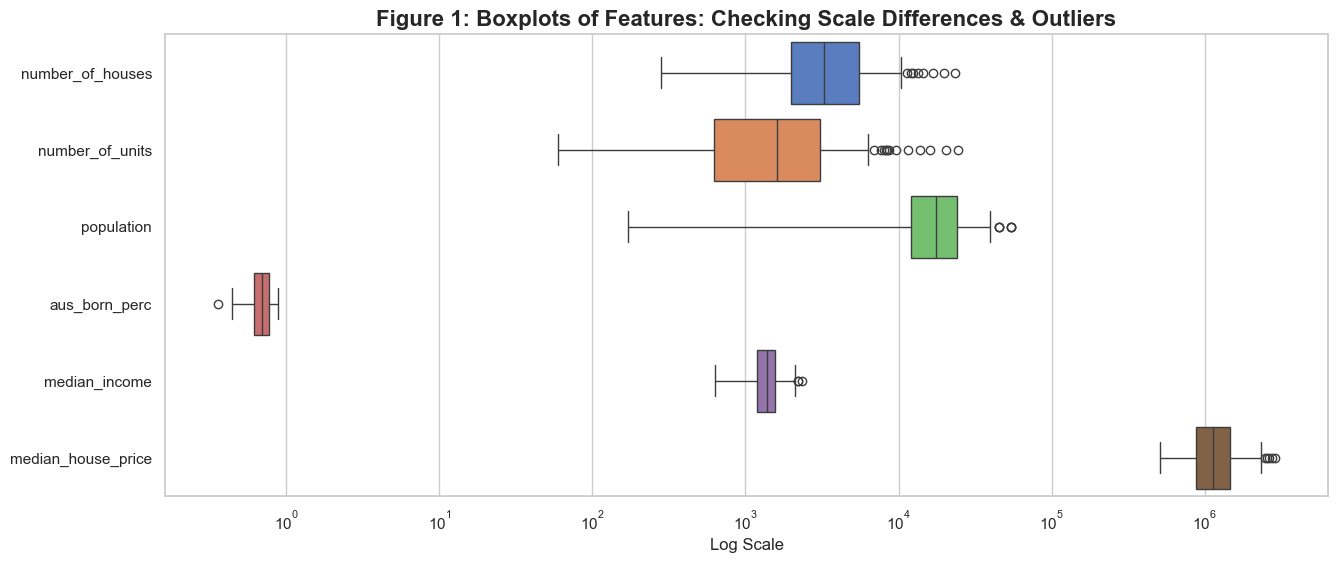

In [7]:
# ==========================================
# Box plots: comparing scale differences and outliers across columns
# ==========================================
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(15, 6))
sns.boxplot(data=df[all_cols], orient="h")
plt.title('Figure 1: Boxplots of Features: Checking Scale Differences & Outliers',
          fontsize=16, fontweight='bold')
plt.xscale('log')   # columns differ greatly in magnitude; a log axis is needed to see them all clearly
plt.xlabel('Log Scale', fontsize=12)
plt.show()

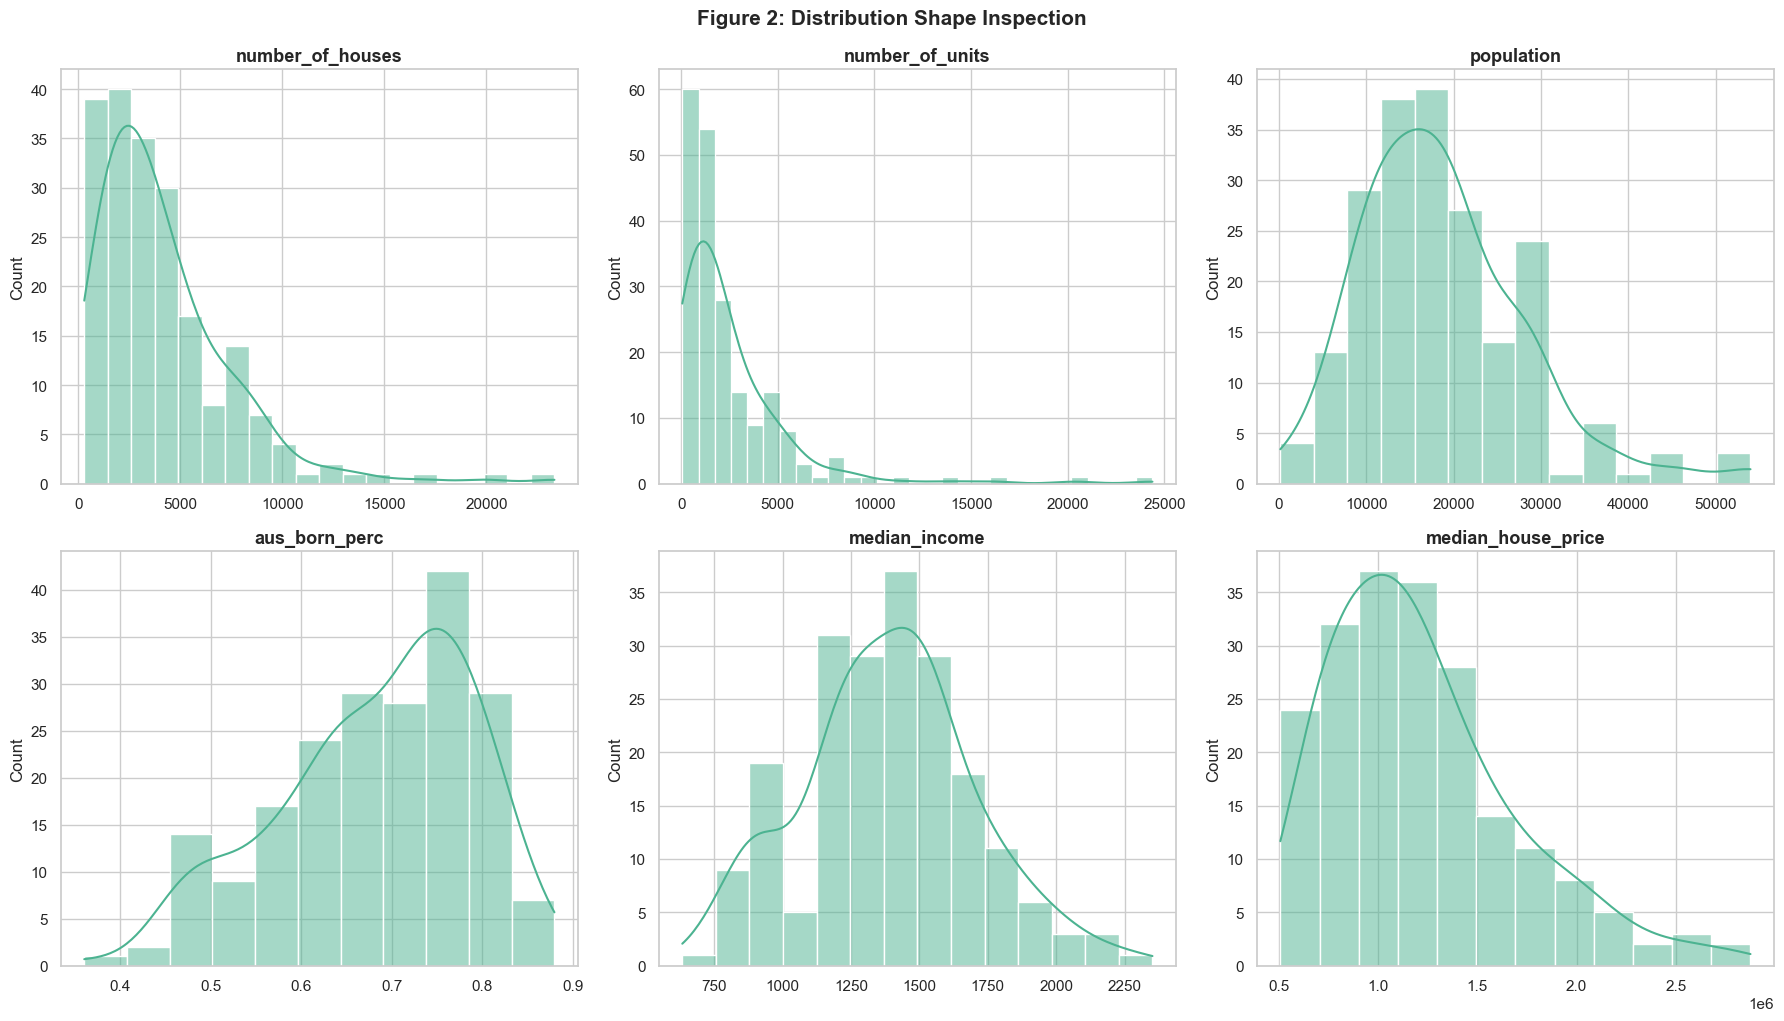

In [8]:
# ==========================================
# Histograms: observing the distribution shape and skewness of each column
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(all_cols):
    data = df[col].dropna()
    sns.histplot(data, kde=True, ax=axes[i], color='#4CB391')
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.suptitle('Figure 2: Distribution Shape Inspection',
             fontsize=15, fontweight='bold', y=1.02)
plt.show()

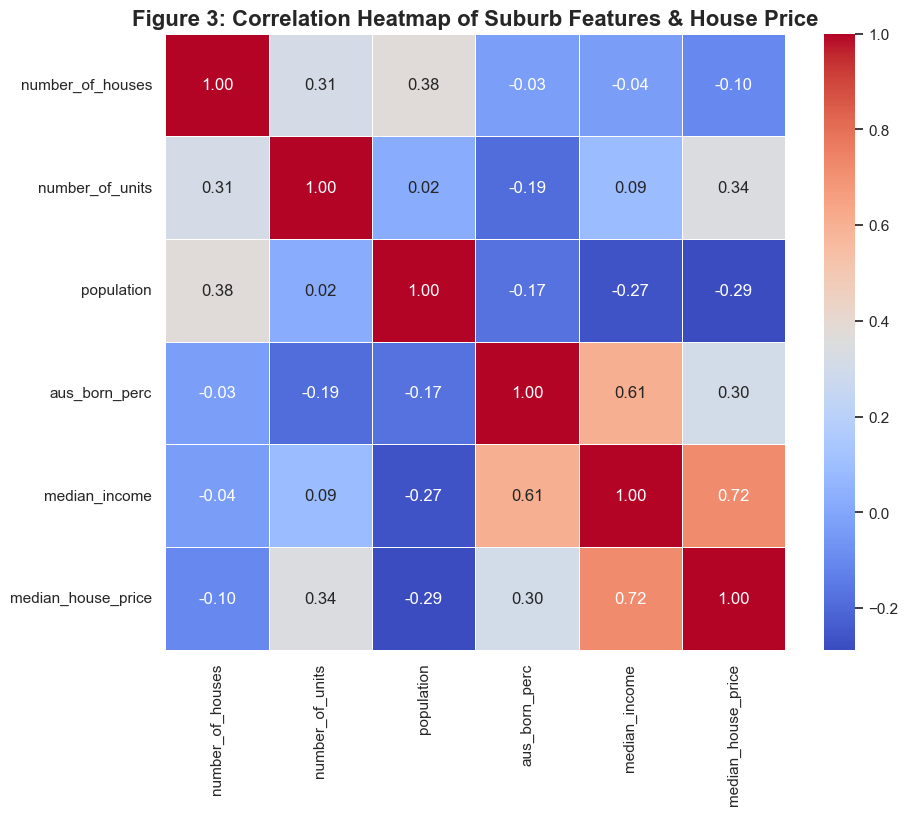

In [9]:
# ==========================================
# Correlation heatmap: quantifying the degree of linear correlation between columns
# ==========================================
plt.figure(figsize=(10, 8))
corr_matrix = df[all_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Figure 3: Correlation Heatmap of Suburb Features & House Price',
          fontsize=16, fontweight='bold')
plt.show()

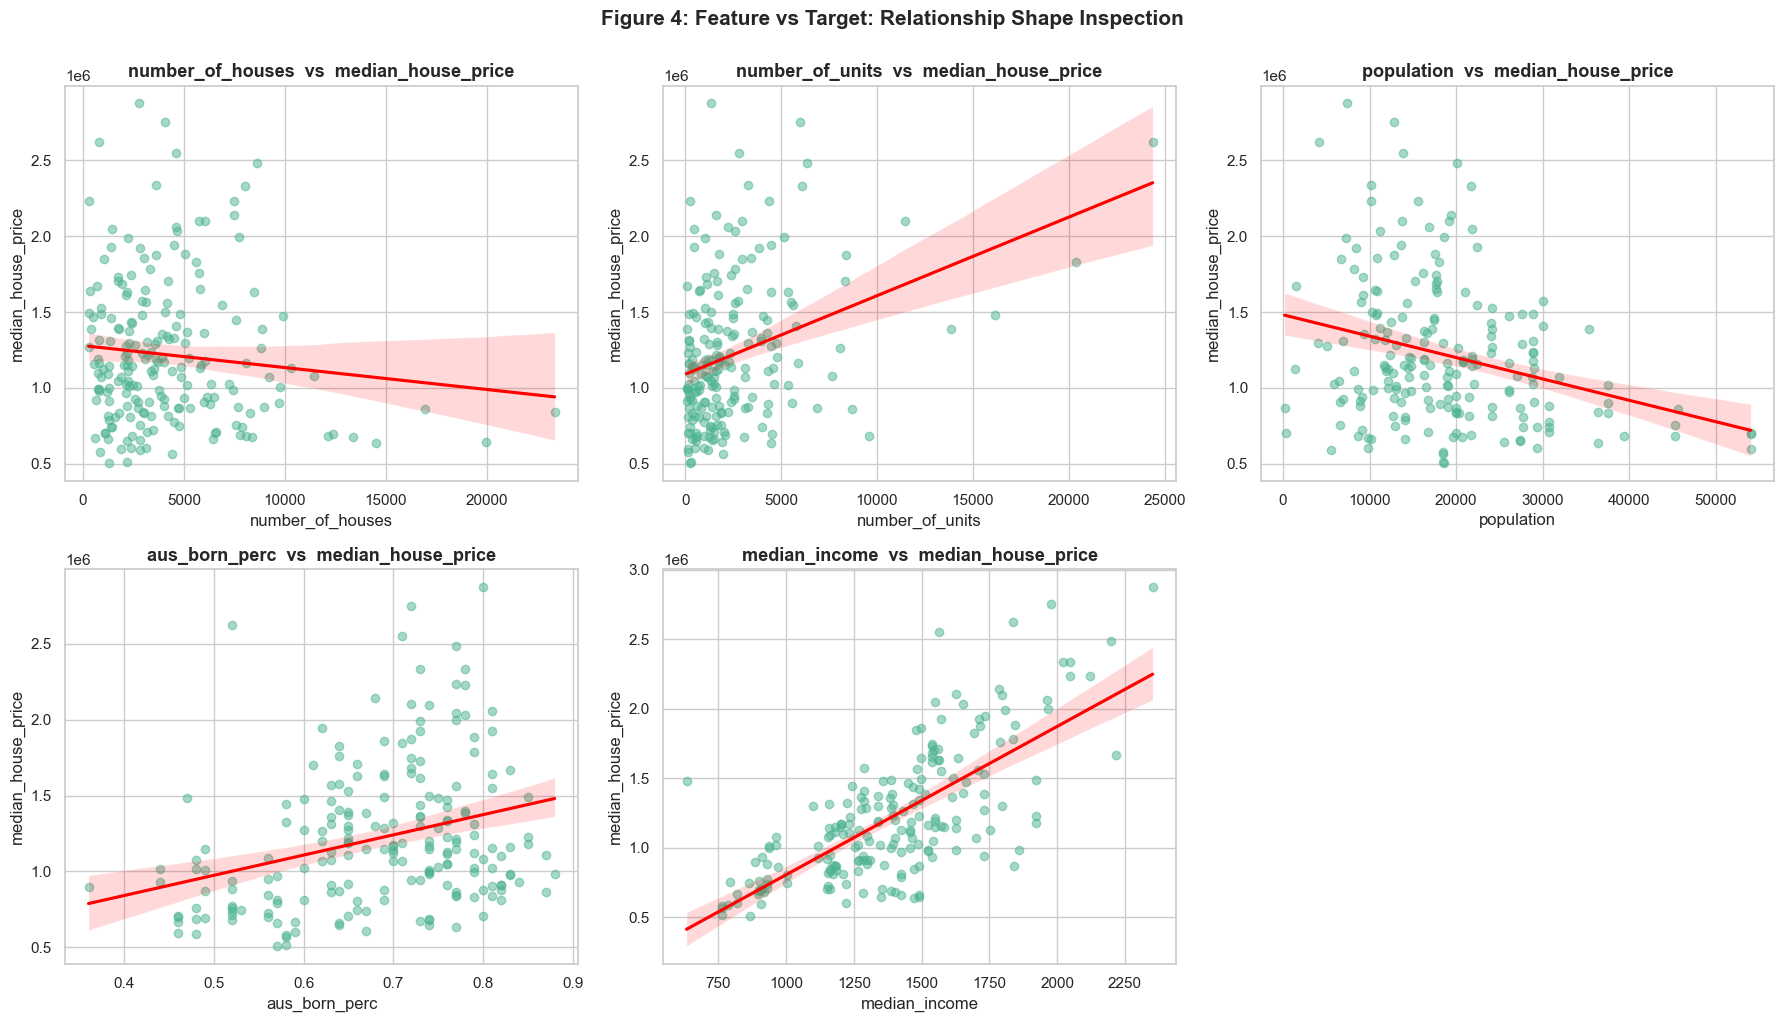

In [10]:
# ==========================================
# Scatter plots: observing the relationship shape between each feature and house price
# ==========================================
plt.figure(figsize=(18, 10))
for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.regplot(data=df, x=col, y=target,
                scatter_kws={'alpha': 0.5, 'color': '#4CB391'},
                line_kws={'color': 'red'})
    plt.title(f'{col}  vs  {target}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.suptitle('Figure 4: Feature vs Target: Relationship Shape Inspection',
             fontsize=15, fontweight='bold', y=1.02)
plt.show()

### 2.2 Statistical Evidence  

In [11]:
# ==========================================
# Table 1: Scale comparison of numerical magnitudes across columns
# ==========================================
desc = df[all_cols].describe().T[['min', 'mean', 'max', 'std']]
print("Table 1: Scale Comparison")
display(desc.round(2))

Table 1: Scale Comparison


,min,mean,max,std
number_of_houses,283.00,4155.77,23338.00,3400.86
number_of_units,60.00,2480.41,24380.00,3132.68
population,170.00,18659.31,54005.00,9604.19
aus_born_perc,0.36,0.68,0.88,0.11
median_income,633.00,1387.94,2352.00,317.84
median_house_price,507200.00,1218816.83,2875800.00,471680.74


In [12]:
# ==========================================
# Table 2: Quantitative skewness diagnosis for each column
# Rule of thumb: |skew| < 0.5 approximately symmetric; 0.5–1 moderately skewed; > 1 highly skewed
# ==========================================
skew_vals = df[all_cols].skew()

# Categorise by the absolute value of skewness
skew_levels = []
for sk in skew_vals:
    if abs(sk) > 1:
        skew_levels.append("Highly Skewed (Transformation Required)")
    elif abs(sk) > 0.5:
        skew_levels.append("Moderately Skewed (Check Case by Case)")
    else:
        skew_levels.append("Approximately Symmetric (No Transformation)")

# Assemble the result table
skew_report = pd.DataFrame({
    'Feature/Variable': skew_vals.index,
    'Skewness Value': skew_vals.values.round(3),
    'Skewness Category': skew_levels
})
skew_report.set_index('Feature/Variable', inplace=True)

print("Table 2: Quantitative Skewness Diagnosis")
display(skew_report)

Table 2: Quantitative Skewness Diagnosis


,Skewness Value,Skewness Category
Feature/Variable,,
number_of_houses,2.156,Highly Skewed (Transformation Required)
number_of_units,3.630,Highly Skewed (Transformation Required)
population,1.086,Highly Skewed (Transformation Required)
aus_born_perc,-0.568,Moderately Skewed (Check Case by Case)
median_income,0.173,Approximately Symmetric (No Transformation)
median_house_price,1.033,Highly Skewed (Transformation Required)


In [13]:
# ==========================================
# Table 3: Correlation between each feature and house price
# Pearson measures linear correlation; Spearman measures monotonic correlation (including non-linear).
# A large gap between the two suggests a possible non-linear component.
# ==========================================
pearson = df[all_cols].corr(method='pearson')[target].drop(target)
spearman = df[all_cols].corr(method='spearman')[target].drop(target)

corr_compare = pd.DataFrame({
    'Pearson (Linear)': pearson.round(3),
    'Spearman (Monotonic)': spearman.round(3),
    '|Difference|': (spearman - pearson).abs().round(3)
})

print("Table 3: Correlation between each feature and median_house_price")
display(corr_compare)

Table 3: Correlation between each feature and median_house_price


,Pearson (Linear),Spearman (Monotonic),|Difference|
number_of_houses,-0.104,-0.058,0.047
number_of_units,0.344,0.309,0.034
population,-0.287,-0.243,0.044
aus_born_perc,0.304,0.295,0.009
median_income,0.719,0.697,0.022


## 3. Shape Transformation & Evaluation

To provide a foundation for the subsequent feature scaling and model training, this section evaluates the data across three dimensions: **distribution skewness (Skewness)**, **model explanatory power (R²)**, and **residual normality (Shapiro-p)**. A complete comparison of the three metrics is presented below.

**Metric 1: Skewness Comparison (Table 4)**  
Evaluation criterion: the closer the absolute value of skewness is to 0, the more symmetric the distribution.

| Feature Column | Original | Log | Sqrt | Box-Cox | Auto-Recommended Optimal Transformation |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **number_of_houses** | 2.156 | -0.442 | 0.762 | -0.006 | Box-Cox |
| **number_of_units** | 3.630 | -0.399 | 1.324 | -0.014 | Box-Cox |
| **population** | 1.086 | -2.645 | -0.029 | 0.100 | Sqrt |
| **aus_born_perc** | -0.568 | -0.924 | -0.738 | -0.129 | Box-Cox |
| **median_income** | 0.173 | -0.502 | -0.166 | -0.008 | Box-Cox |
| **median_house_price** | 1.033 | 0.173 | 0.593 | 0.014 | Box-Cox |

**Metric 2: Coefficient of Determination Comparison (Table 5)**  
Evaluation criterion: the larger the R², the stronger the linear explanatory power of the feature for house price.

| Feature | Original R² | Log R² | Sqrt R² | Box-Cox R² | R²-Optimal Transformation |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **number_of_houses** | 0.0109 | 0.0035 | 0.0057 | 0.0039 | Original |
| **number_of_units** | 0.1182 | 0.0997 | 0.1262 | 0.1094 | Sqrt |
| **population** | 0.0825 | 0.0245 | 0.0627 | 0.0653 | Original |
| **aus_born_perc** | 0.0923 | 0.0995 | 0.0963 | 0.0778 | Log |
| **median_income** | 0.5175 | 0.4662 | 0.4950 | 0.5063 | Original |

**Metric 3: Residual Normality Comparison (Table 6)**  
Evaluation criterion: the larger the Shapiro-p, the closer the residuals are to the normality assumption.

| Feature | Original Shapiro-p | Log Shapiro-p | Sqrt Shapiro-p | Box-Cox Shapiro-p | Residual-Optimal Recommendation |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **number_of_houses** | 0.7027 | 0.5860 | 0.6410 | 0.6007 | Original |
| **number_of_units** | 0.3933 | 0.1529 | 0.3595 | 0.1807 | Original |
| **population** | 0.3688 | 0.4176 | 0.3869 | 0.3866 | Log |
| **aus_born_perc** | 0.2072 | 0.2769 | 0.2355 | 0.1447 | Log |
| **median_income** | 0.0046 | 0.0003 | 0.0009 | 0.0020 | Original |


**Decision Basis (Statistical Justification)**

In the feature engineering of the linear regression model, when the various statistical metrics diverge, this model follows the following core guiding principle: "Highly skewed features should give priority to distribution correction in order to preserve the homoscedasticity assumption; features that are approximately symmetric should give priority to their original form in order to retain single-feature explanatory power and economic meaning."

**1. Number of Houses (number_of_houses)**
* **Quantitative metrics**: The original skewness is +2.156, belonging to a highly right-skewed long-tailed distribution.
* **Decision analysis**: Although keeping the original form is slightly superior in terms of model explanatory power R² (0.0109 vs Box-Cox's 0.0039) and residual normality p-value (0.7027 vs Box-Cox's 0.6007). However, this is not only because the R² is extremely low (less than 0.02, indicating weak correlation), but more importantly, if such an extreme long tail is not handled, it would violate the homoscedasticity assumption of the OLS model, causing an obvious "funnel-shaped" heteroscedastic divergence in the high-prediction-value region.
* **Final decision**: Use the Box-Cox transformation. At the cost of a small R² loss, it compresses the skewness to the symmetric range of -0.006, shrinking the extreme long tail and reducing the high-leverage-point risk for the model.

**2. Number of Units (number_of_units)**
* **Quantitative metrics**: This feature is the most severely skewed variable in the entire dataset, with an original skewness reaching +3.630.
* **Decision analysis**: Among all transformations, Sqrt yields the highest R² (0.1262), but its correction strength is still insufficient (the skewness after transformation is still 1.324, indicating high skewness). By comparison, although Box-Cox has the second-highest R² (0.1094) and its residual Shapiro-p performs worse than the original form (0.1807 vs 0.3933), its p-value is still greater than 0.05, holding the baseline of the normality assumption.
* **Final decision**: Use the Box-Cox transformation. In the face of high skewness, the symmetry of the data distribution must be guaranteed first and foremost. Box-Cox corrects its skewness from +3.630 to -0.014, significantly improving the data shape.

**3. Population (population)**
* **Quantitative metrics**: The original skewness is +1.086, presenting a moderately right-skewed state.
* **Decision analysis**: Although the Original form retains the highest R² (0.0825, with Sqrt slightly decreasing to 0.0627), after applying the Sqrt (square root) transformation, the skewness is perfectly corrected to -0.029. At the same time, in the residual normality test, the p-value of the Sqrt transformation reaches 0.3869, which not only far exceeds the significance threshold of 0.05 but is also almost identical to the performance of the optimal Log transformation (p = 0.4176), while avoiding the extreme left-skew reversal (-2.645) caused by the Log transformation.
* **Final decision**: Adopt the Sqrt transformation. While correcting the moderate skewness, it is gentler than the Log transformation and retains a reasonable fitting space for the relationship between population base changes and house price.

**4. Proportion of Australian-Born Population (aus_born_perc)**
* **Quantitative metrics**: The original skewness is -0.568, presenting a mild left skew, and the distribution is relatively healthy.
* **Decision analysis**: Although the Log transformation can slightly improve R² (from 0.0923 to 0.0995) and residual performance (the p-value rises from 0.2072 to 0.2769), the performance of the original data is in fact already satisfactory (the p-value of 0.2072 is far greater than the passing line of 0.05, and the residuals are relatively healthy). Since the original data already satisfies the prerequisite assumptions of linear regression, there is no need to perform a non-linear transformation for this tiny numerical improvement.
* **Final decision**: Keep the Original (original state). As a naturally occurring percentage (Percentage) data, retaining the original form keeps its own business meaning intuitive.

**5. Median Income (median_income)**
* **Quantitative metrics**: The original skewness of this feature is only +0.173, and it is already highly close to the standard normal distribution.
* **Decision analysis**: Without any transformation, the income feature not only has the highest R² of all (0.5175, i.e., a single variable alone can explain more than 51% of the variance in house price), but any non-linear transformation (such as Box-Cox or Log) would cause R² to decline to varying degrees.
* **Final decision**: Keep the Original (original state). Any transformation (such as Box-Cox, although it can reduce the skewness to -0.008) is redundant; retaining the original form maintains the strongest explanatory power.

### 3.1 Skewness Correction Comparison

In [14]:
# ==========================================
# Compute the 4 transformations and store them in a dictionary for later use
# Compute Original / Log / Sqrt / Box-Cox separately for the 6 columns
# ==========================================
transformed_dict = {}
boxcox_lambdas = {}

for col in all_cols:
    x = df[col].values.astype(float)

    # Box-Cox automatically selects the optimal λ
    xb, lam = stats.boxcox(x)
    boxcox_lambdas[col] = lam

    transformed_dict[col] = {
        'Original': x,
        'Log':      np.log(x),
        'Sqrt':     np.sqrt(x),
        'Box-Cox':  xb,
    }

In [15]:
# ==========================================
# Table 4: Skewness comparison of each column under the 4 transformations
# ==========================================
methods = ['Original', 'Log', 'Sqrt', 'Box-Cox']
summary = []

for col in all_cols:
    versions = transformed_dict[col]
    summary.append({
        'Feature Column': col,
        'Original': round(stats.skew(versions['Original'], bias=False), 3),
        'Log':      round(stats.skew(versions['Log'],      bias=False), 3),
        'Sqrt':     round(stats.skew(versions['Sqrt'],     bias=False), 3),
        'Box-Cox':  round(stats.skew(versions['Box-Cox'],  bias=False), 3),
    })

skew_table = pd.DataFrame(summary).set_index('Feature Column')
skew_table['Optimal Transformation'] = skew_table[methods].abs().idxmin(axis=1)

print("Table 4: Skewness comparison of each column under the 4 transformations")
display(skew_table)

Table 4: Skewness comparison of each column under the 4 transformations


,Original,Log,Sqrt,Box-Cox,Optimal Transformation
Feature Column,,,,,
number_of_houses,2.156,-0.442,0.762,-0.006,Box-Cox
number_of_units,3.630,-0.399,1.324,-0.014,Box-Cox
population,1.086,-2.645,-0.029,0.100,Sqrt
aus_born_perc,-0.568,-0.924,-0.738,-0.129,Box-Cox
median_income,0.173,-0.502,-0.166,-0.008,Box-Cox
median_house_price,1.033,0.173,0.593,0.014,Box-Cox


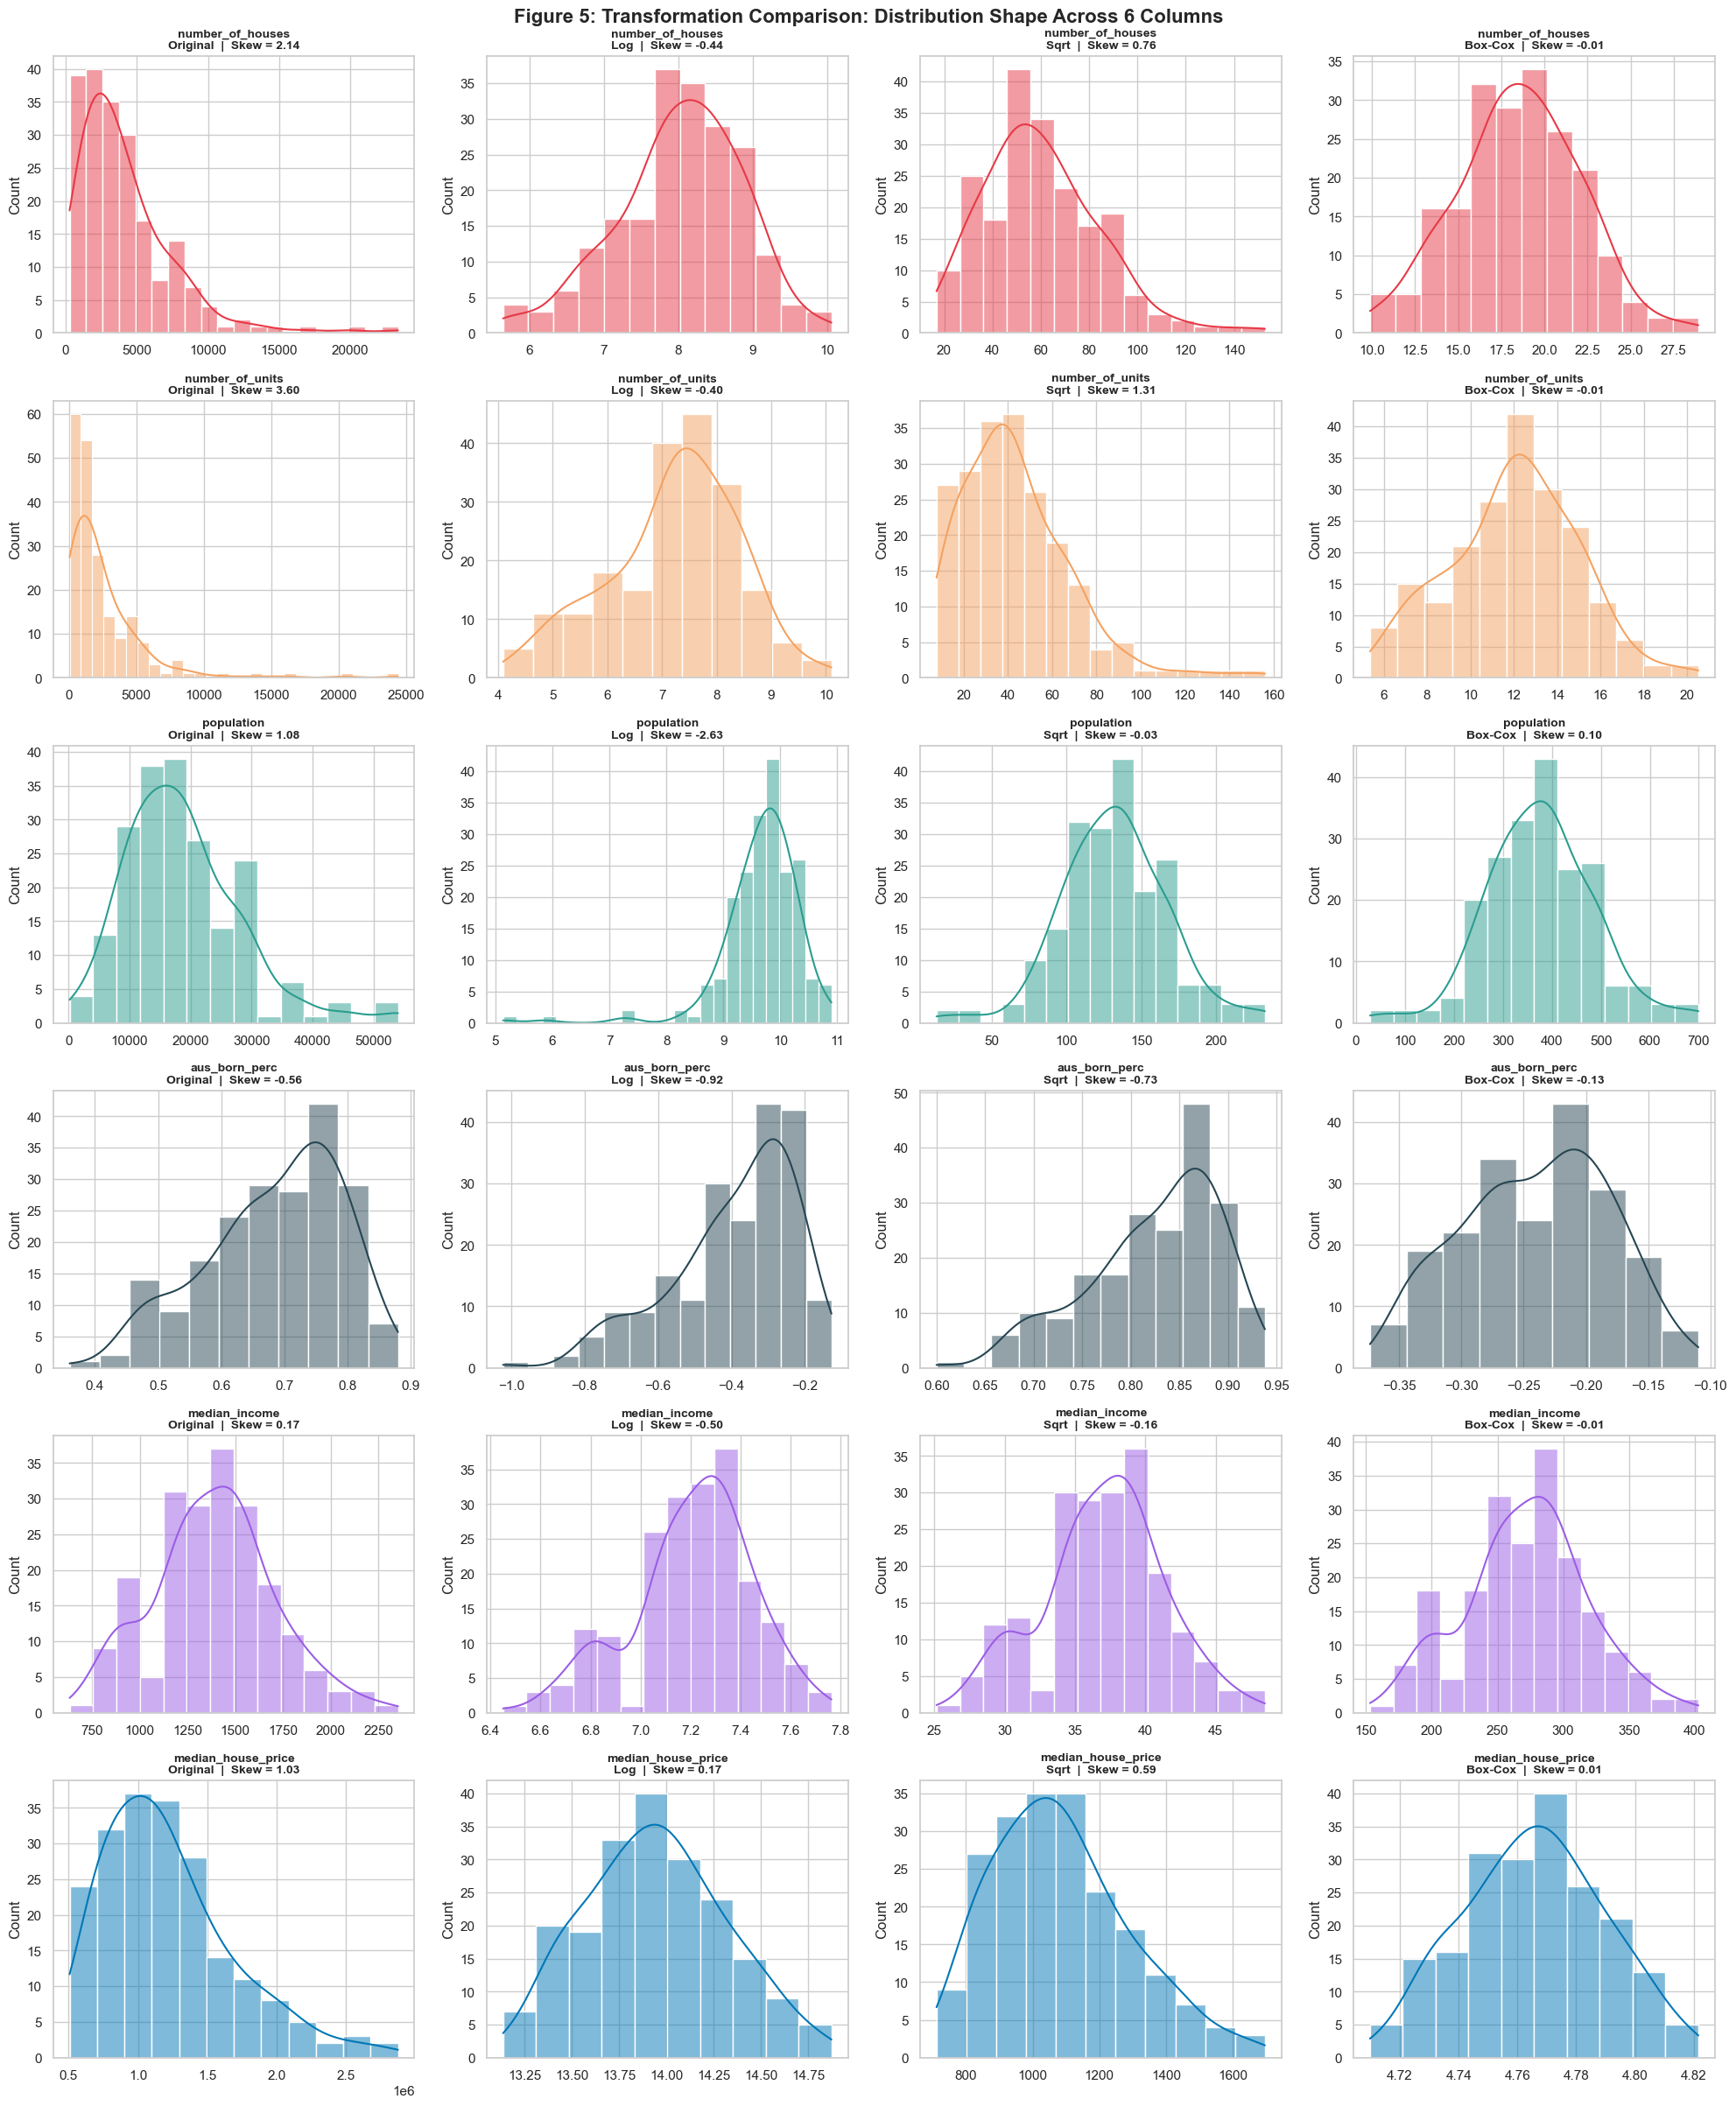

In [16]:
# ==========================================
# Figure 5: Distribution shape comparison of each column under the 4 transformations
# ==========================================

# Assign one colour to each variable
palette = ['#E63946',  # number_of_houses
           '#F4A261',  # number_of_units
           '#2A9D8F',  # population
           '#264653',  # aus_born_perc
           '#9B5DE5',  # median_income
           '#0077B6']  # median_house_price

fig, axes = plt.subplots(len(all_cols), 4, figsize=(20, 4 * len(all_cols)))

for i, col in enumerate(all_cols):
    color = palette[i]
    versions = transformed_dict[col]

    for j, (name, data) in enumerate(versions.items()):
        ax = axes[i, j]
        sns.histplot(data, kde=True, ax=ax, color=color)
        ax.set_title(f'{col}\n{name}  |  Skew = {stats.skew(data):.2f}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('')

plt.tight_layout()
plt.suptitle('Figure 5: Transformation Comparison: Distribution Shape Across 6 Columns',
             fontsize=16, fontweight='bold', y=1.002)
plt.show()

### 3.2 Coefficient of Determination (R²) Comparison

In [ ]:
# ==========================================
# Table 5: Single-feature linear regression R² comparison under the 4 transformations
# A higher R² means the transformed feature has a stronger linear relationship with house price
# ==========================================
# 不过我还是有点担心会问我为什么选择的用原始y而不是在这个部分就直接跟3.3一样进行boxcox后，进行这个决定系数之前的比较
y_raw = transformed_dict[target]['Original'].reshape(-1, 1)   # raw house price, used as a fixed baseline

r2_rows = []
for col in features:
    versions = transformed_dict[col]

    row = {'Feature': col}
    for name in ['Original', 'Log', 'Sqrt', 'Box-Cox']:
        xt = versions[name]   # transformed x = 变换后的特征
        # Use the transformed feature xt to predict the fixed raw house price y_raw
        lr = LinearRegression().fit(xt.reshape(-1, 1), y_raw)
        row[name + ' R²'] = round(r2_score(y_raw, lr.predict(xt.reshape(-1, 1))), 4)    #  拿真实房价和预测房价对比,算出一个分数 R²(这个函数专门打分用的)
    r2_rows.append(row)

r2_table = pd.DataFrame(r2_rows).set_index('Feature')
r2_table['Optimal Transformation'] = r2_table.idxmax(axis=1).str.replace(' R²', '', regex=False)

print("Table 5: Coefficient of Determination R² Comparison") 
display(r2_table)

Table 5: Coefficient of Determination R² Comparison


,Original R²,Log R²,Sqrt R²,Box-Cox R²,Optimal Transformation
Feature,,,,,
number_of_houses,0.0109,0.0035,0.0057,0.0039,Original
number_of_units,0.1182,0.0997,0.1262,0.1094,Sqrt
population,0.0825,0.0245,0.0627,0.0653,Original
aus_born_perc,0.0923,0.0995,0.0963,0.0778,Log
median_income,0.5175,0.4662,0.4950,0.5063,Original


### 3.3 Residual Normality Comparison

**Target Variable Anchoring**
Because the original skewness of the target variable `median_house_price` is as high as +1.033, in order to satisfy the core assumption of linear regression regarding residual normality, we must first address the long-tail distortion of the target variable itself. Statistical experience shows that **the extreme non-normal distribution of the target variable is often the root cause of the model residuals failing to follow normality**. Formally, if the target variable Y possesses a severely right-skewed long-tailed distribution (skewness γ₁ ≫ 0), then since the residual is defined as εᵢ = Yᵢ − Ŷᵢ and the fitted values Ŷᵢ are merely a location-scale (linear) function of the predictors, the residuals εᵢ will almost inevitably inherit this asymmetry (γ₁(ε) ≠ 0), thereby violating the OLS normality assumption εᵢ ~ N(0, σ²) and guaranteeing a rejection of H₀ in the Shapiro–Wilk test. Critically, this failure would not be the fault of the feature X, but purely a consequence of the target variable Y being too skewed and dragging the residuals along with it.

Therefore, based entirely on distributional evidence, we directly applied a Box-Cox transformation to the target variable, correcting its skewness to the absolutely symmetric state of +0.014. Only after Y is corrected to be approximately symmetric do the residuals have a chance to be normal — and only then does the Shapiro test result genuinely reflect how well a given feature and its fitted line capture the relationship, rather than being contaminated by the long tail of Y. Accordingly, in all subsequent single-feature residual tests, **we consistently use this transformed target variable as the fixed baseline**.


> **Notation:**
> - **γ₁** — skewness; γ₁ ≫ 0 indicates a severe right skew.
> - **εᵢ = Yᵢ − Ŷᵢ** — the i-th residual (actual value − predicted value).
> - **Ŷᵢ** — the fitted (predicted) value. It is only a location-scale (linear) transformation of the predictors; precisely because it is merely a linear shift-and-scale, it cannot "straighten out" the skew of Y, so the skew is passed on to the residuals unchanged.
> - **γ₁(ε) ≠ 0** — the skewness of the residuals is non-zero (i.e., the residuals are also skewed).
> - **εᵢ ~ N(0, σ²)** — the OLS residual-normality assumption.
> - **H₀** — the null hypothesis of the Shapiro–Wilk test (residuals follow a normal distribution); rejecting it means the test fails.

In [18]:
# ==========================================
# Table 6: Residual normality comparison of each feature under the 4 transformations
# Residuals are tested with the Shapiro-Wilk test; a larger p-value means closer to normal
# y consistently uses the Box-Cox-transformed house price (matching the final modelling setup)
# ==========================================
rows = []
# Take the Box-Cox version of the house price
y_bc = transformed_dict[target]['Box-Cox']

def get_shapiro_p(x_data, y_data):
    """Fit a single-feature regression and return the Shapiro-Wilk p-value of the residuals"""
    lr = LinearRegression().fit(x_data.reshape(-1, 1), y_data)
    res = y_data - lr.predict(x_data.reshape(-1, 1))
    return round(st.shapiro(res).pvalue, 4)

for col in features:
    feat_dict = transformed_dict[col]

    rows.append({
        'Feature': col,
        'Original Shapiro-p': get_shapiro_p(feat_dict['Original'], y_bc),
        'Log Shapiro-p':      get_shapiro_p(feat_dict['Log'], y_bc),
        'Sqrt Shapiro-p':     get_shapiro_p(feat_dict['Sqrt'], y_bc),
        'Box-Cox Shapiro-p':  get_shapiro_p(feat_dict['Box-Cox'], y_bc),
    })

resid_table = pd.DataFrame(rows).set_index('Feature')

methods = ['Original Shapiro-p', 'Log Shapiro-p', 'Sqrt Shapiro-p', 'Box-Cox Shapiro-p']
resid_table['Optimal Recommendation'] = resid_table[methods].idxmax(axis=1).str.replace(' Shapiro-p', '', regex=False)

print("Table 6: Residual normality comparison of each feature under different transformations")
display(resid_table)

Table 6: Residual normality comparison of each feature under different transformations


,Original Shapiro-p,Log Shapiro-p,Sqrt Shapiro-p,Box-Cox Shapiro-p,Optimal Recommendation
Feature,,,,,
number_of_houses,0.7027,0.5860,0.6410,0.6007,Original
number_of_units,0.3933,0.1529,0.3595,0.1807,Original
population,0.3688,0.4176,0.3869,0.3866,Log
aus_born_perc,0.2072,0.2769,0.2355,0.1447,Log
median_income,0.0046,0.0003,0.0009,0.0020,Original


### 3.4 Applying Transformations to Each Feature Based on Section Decisions

In [19]:
# ==========================================
# Apply shape correction: transform each feature based on the Section 3.5 decisions
# ==========================================
# 1. Copy the data and operate on the copy 
data_skew_fixed = df.copy()

# 2. Group features by the Section 3.5 conclusions 
features_to_boxcox = ['number_of_houses', 'number_of_units']
features_to_sqrt   = ['population']
features_to_keep   = ['median_income', 'aus_born_perc']
target_col = 'median_house_price'

all_features = features_to_boxcox + features_to_sqrt + features_to_keep

# 3. Apply the transformations
boxcox_transformer = PowerTransformer(method='box-cox', standardize=False)
data_skew_fixed[features_to_boxcox] = boxcox_transformer.fit_transform(data_skew_fixed[features_to_boxcox])

data_skew_fixed[features_to_sqrt] = np.sqrt(data_skew_fixed[features_to_sqrt])

target_transformer = PowerTransformer(method='box-cox', standardize=False)
data_skew_fixed[[target_col]] = target_transformer.fit_transform(data_skew_fixed[[target_col]])

# 4. Preview the result and self-check the corrected skewness
print("Shape-Corrected Dataset Preview (Skewness Fixed, Not Yet Scaled)")
display(data_skew_fixed.head())

print("\nSkewness Check (after correction):")
for col in all_features + [target_col]:
    print(f" - {col:<20} : Post-Transformation Skewness = {data_skew_fixed[col].skew():.3f}")

Shape-Corrected Dataset Preview (Skewness Fixed, Not Yet Scaled)


,municipality,number_of_houses,number_of_units,population,aus_born_perc,median_income,median_house_price
suburb,,,,,,,
ABBOTSFORD,Yarra,17.055836,15.165918,63.442888,0.68,1797.0,4.775093
ABERFELDIE,Moonee Valley,15.121839,9.243471,149.806542,0.81,1571.0,4.799038
ALBANVALE,Brimbank,16.269490,6.845926,232.389759,0.46,907.0,4.721667
ALBION,Brimbank,15.065430,11.865200,175.148508,0.52,929.0,4.737401
ALPHINGTON,Darebin,15.904075,11.281794,96.057275,0.73,1538.0,4.792663



Skewness Check (after correction):
 - number_of_houses     : Post-Transformation Skewness = -0.006
 - number_of_units      : Post-Transformation Skewness = -0.014
 - population           : Post-Transformation Skewness = -0.029
 - median_income        : Post-Transformation Skewness = 0.173
 - aus_born_perc        : Post-Transformation Skewness = -0.568
 - median_house_price   : Post-Transformation Skewness = 0.014


## 4. Feature Scaling

After completing Part 3, in which we determined the appropriate skewness-correction method for each feature, we then considered two candidate scaling methods on this basis: **Standardisation** (zero mean, unit variance) and **Min-Max normalisation** (rescaling the data to the [0, 1] range). As shown in Table 7, both methods successfully eliminate the scale discrepancy — Standardisation unifies the mean of all columns to ≈ 0 (e.g., `number_of_houses` changes from 18.509 to -0.0) and the standard deviation to ≈ 1.002, but its min/max boundaries are not fixed (e.g., `population` ranges from -3.349 to 2.831 after scaling); whereas Min-Max strictly compresses every feature into the fixed [0, 1] range, with the min of all columns being 0.0, the max being 1.0, and the range being 1.0. Since the table itself can only prove that both methods are effective, the final choice must depend on the downstream model rather than on the scaling result itself.

**Decision Basis: Model Type (Core Criterion)**

This assignment builds an Ordinary Least Squares (OLS) linear regression model. Combined with the Box-Cox / Sqrt transformations applied in Section 3 to correct skewness, as well as the subsequent residual-normality checks, this entire framework of statistical assumptions pairs naturally with **Standardisation**. After standardisation, the data has a mean of 0 and a variance of 1, which does not distort the shape of the distribution, and the regression coefficients become more interpretable — each coefficient represents the change in house price when the corresponding feature varies by one standard deviation. In contrast, Min-Max normalisation is more suited to models that require bounded inputs (such as neural networks) and is highly sensitive to residual extreme values, making it unsuitable for this task.

**Conclusion:** For this scenario, **Standardisation** is selected as the feature scaling method.

### 4.1 Statistical Evidence

In [20]:
# ==========================================
# Table 7: Scale comparison of each column before and after scaling
# Data continues from data_skew_fixed, corrected in Section 3
# ==========================================

# 1. Compute both Standardisation and Min-Max scaling for the 5 independent variables
data_standardised = pd.DataFrame(
    StandardScaler().fit_transform(data_skew_fixed[features]),
    columns=features, index=data_skew_fixed.index
)

data_minmax = pd.DataFrame(
    MinMaxScaler().fit_transform(data_skew_fixed[features]),
    columns=features, index=data_skew_fixed.index
)

# 2. Define function: summarise the mean/std/min/max and range of each column
def scale_summary(data, name):
    """Extract the mean/std/min/max of each column and compute the range to reflect the scale span"""
    s = data.describe().T[['mean', 'std', 'min', 'max']]
    s['Range (max-min)'] = (s['max'] - s['min']).round(2)
    s.columns = pd.MultiIndex.from_product([[name], s.columns])
    return s.round(3)

# 3. Horizontally concatenate the three states for comparison: Before Scaling / Standardised / Min-Max
compare_scale = pd.concat([
    scale_summary(data_skew_fixed[features], 'Before Scaling (Skew-Fixed)'),
    scale_summary(data_standardised,         'Standardised'),
    scale_summary(data_minmax,               'Min-Max'),
], axis=1)

print("Table 7: Scale comparison before and after scaling")
display(compare_scale)

Table 7: Scale comparison before and after scaling


Before Scaling (Skew-Fixed)                              \
                                        mean      std      min       max   
number_of_houses                      18.509    3.566    9.883    28.926   
number_of_units                       12.010    2.946    5.369    20.516   
population                           131.907   35.584   13.038   232.390   
aus_born_perc                          0.684    0.108    0.360     0.880   
median_income                       1387.936  317.841  633.000  2352.000   

                                 Standardised                       \
                 Range (max-min)         mean    std    min    max   
number_of_houses           19.04         -0.0  1.002 -2.425  2.928   
number_of_units            15.15          0.0  1.002 -2.260  2.894   
population                219.35         -0.0  1.002 -3.349  2.831   
aus_born_perc               0.52          0.0  1.002 -3.015  1.829   
median_income            1719.00         -0.0  1.002 -2.381  3.041   

                                 Min-Max                                   
                 Range (max-min)    mean    std  min  max Range (max-min)  
number_of_houses            5.35   0.453  0.187  0.0  1.0             1.0  
number_of_units             5.15   0.438  0.194  0.0  1.0             1.0  
population                  6.18   0.542  0.162  0.0  1.0             1.0  
aus_born_perc               4.84   0.622  0.207  0.0  1.0             1.0  
median_income               5.42   0.439  0.185  0.0  1.0             1.0

### 4.2 Scale Transformation

In [21]:
# ==========================================
# 4. Generate the final dataset: apply Standardisation to the 5 features, leave the target (y) corrected but unscaled
# ==========================================
final_scaled_data = data_skew_fixed.copy()

# Apply the standardised values only to the 5 features; keep y as Box-Cox transformed
final_scaled_data[features] = data_standardised[features]

print("Final Dataset (Skewness Corrected + Features Scaled)")
display(final_scaled_data.head())

Final Dataset (Skewness Corrected + Features Scaled)


,municipality,number_of_houses,number_of_units,population,aus_born_perc,median_income,median_house_price
suburb,,,,,,,
ABBOTSFORD,Yarra,-0.408424,1.074045,-1.928795,-0.034127,1.290206,4.775093
ABERFELDIE,Moonee Valley,-0.952056,-0.941337,0.504284,1.176908,0.577392,4.799038
ALBANVALE,Brimbank,-0.629460,-1.757211,2.830857,-2.083570,-1.516891,4.721667
ALBION,Brimbank,-0.967912,-0.049174,1.218230,-1.524631,-1.447502,4.737401
ALPHINGTON,Darebin,-0.732175,-0.247705,-1.009967,0.431656,0.473309,4.792663


## 5. Recommended Transformation Set

Based on the combined analysis from Section 3 (three lines of evidence: skewness, R², and residual normality) and Section 4 (scale), the final recommended preprocessing plan for the 5 features and the target variable is presented below.

### 5.1 Recommended Plan Summary Table

| Column | Role | Skewness Correction | Scaling | Selection Rationale (Brief) — See Section 3 for Details |
| :--- | :--- | :--- | :--- | :--- |
| **number_of_houses** | Feature | Box-Cox | Standardisation | Original skewness +2.156 (highly right-skewed); R² is extremely low (<0.02) with no explanatory power to preserve; at the cost of a small R² loss, skewness is corrected to -0.006, shrinking the extreme long tail to indirectly maintain the Homoscedasticity assumption |
| **number_of_units** | Feature | Box-Cox | Standardisation | Most severely skewed (+3.630); Sqrt correction is insufficient (skewness after transformation still reaches 1.324); Box-Cox corrects skewness to -0.014, and the residual p-value of 0.1807 still > 0.05, holding the Normality baseline |
| **population** | Feature | Sqrt | Standardisation | Moderately right-skewed (+1.086); Sqrt corrects skewness to -0.029, with residual p = 0.3869 close to Log, while avoiding the extreme left-skew reversal (-2.645) caused by Log |
| **aus_born_perc** | Feature | No Transformation (Original) | Standardisation | Mildly left-skewed (-0.568); original residual p-value of 0.2072 already far exceeds the 0.05 threshold; as natural percentage data, the original form is retained under the parsimony principle to preserve business meaning |
| **median_income** | Feature | No Transformation (Original) | Standardisation | Skewness of only +0.173 is already close to normal; original R² is the highest (0.5175), with a single variable explaining over 51% of the variance in house price, corresponding to the OLS Linearity assumption — any transformation would reduce explanatory power. Shapiro-p under all transformations is < 0.05; the residual non-normality stems from the intrinsic data structure and cannot be fixed by shape transformations. According to the Central Limit Theorem, under the current sample size (n ≈ 200+), the OLS estimator itself is asymptotically normal, and the credibility of statistical inference is not affected. Therefore, Original is retained to maximise explanatory power. |
| **median_house_price** | Target | Box-Cox | No Scaling | Original skewness +1.033 (highly right-skewed); Box-Cox corrects skewness to +0.014. The skewness of the target variable is the root source of residual non-Normality; only after Y's skewness is corrected do the residuals have a chance of satisfying the OLS assumption. No scaling is needed, as the result can subsequently be restored to the true house price via the inverse Box-Cox transformation. |


- **Why all 5 features use Standardisation rather than Min-Max Normalisation:** 
Even after skewness correction, significant magnitude differences still exist across features (e.g., `number_of_houses` has a mean of about 18,500 vs. `aus_born_perc` with a mean of 0.68 — a ten-thousand-fold difference). If fed directly into an OLS model, features with large magnitudes would dominate gradient updates and coefficient sizes, and coefficients with different units cannot be compared horizontally. Both scaling methods can eliminate magnitude differences, but this study chooses **Standardisation** over Min-Max for three core reasons:

  1. **Statistically aligned with the chosen transformations** — Section 3 has already applied Box-Cox / Sqrt to correct skewness, aiming to align the data shape with the normality and homoscedasticity prerequisites of OLS. Standardisation is a **linear shift and scaling** (subtract the mean, divide by the standard deviation) that **does not alter the distribution shape** (skewness, kurtosis, and symmetry are all preserved), allowing it to losslessly inherit the corrections from Section 3. While Min-Max is also a linear transformation that does not alter shape, its design goal is "compression into a fixed interval" rather than "unifying statistical scale," and it does not directly dialogue with the OLS assumption framework.

  2. **More robust to extreme values and future samples** — Min-Max's boundaries are determined by the current sample's min/max. Once outliers are introduced into the data, the entire [0,1] interval is "stretched" by the outlier, and normal samples are squeezed into a very narrow subinterval; moreover, if future samples fall outside the existing min/max, the entire scale must be recalculated. Standardisation is based on the mean and standard deviation, with all samples participating in the calculation, so the impact of a single outlier is diluted; new samples only need to apply the existing μ and σ for standardisation, making it **more suitable as a reusable preprocessing pipeline**.

  3. **Regression coefficients gain clear statistical interpretation** — After Standardisation, all features have mean ≈ 0 and std ≈ 1, and the resulting regression coefficient β_j represents "the expected change in the target variable when feature j changes by 1 standard deviation," meaning **coefficients can be directly compared horizontally to assess feature importance**. After Min-Max, the coefficient becomes "the change in the target when feature j goes from its minimum to its maximum value," an interpretation that depends on the sample extremes and lacks statistical comparability.

  **Summary:** Min-Max is generally more suitable for models that require **bounded inputs**; for this task of OLS linear regression, Standardisation is more appropriate across the three dimensions of statistical assumptions, robustness, and interpretability.

- **Why the target variable is only corrected but not scaled:** Box-Cox is used to improve residual normality (one of the statistical assumptions of linear regression). However, scaling the target variable does not change the model's goodness of fit and instead makes it difficult to inverse-transform the predicted results back to the true house price. Therefore, the target undergoes only Box-Cox without scaling.

- **Correspondence between the four OLS assumptions and the decisions in this study:** The validity of Ordinary Least Squares (OLS) relies on four core assumptions: **Linearity**, **Independence**, **Homoscedasticity**, and **Normality of Residuals**. This dataset is cross-sectional, so the independence assumption is satisfied by default; linearity is assessed via the R² metric in Table 5; residual normality is directly verified via the Shapiro-Wilk test in Table 6. Although homoscedasticity was not assessed via an explicit statistical test such as Breusch-Pagan, severe skewness typically leads to funnel-shaped heteroscedasticity through the "larger value, larger fluctuation" data generation mechanism. Therefore, applying Box-Cox / Sqrt transformations to highly skewed features essentially **reduces heteroscedasticity risk at the source by shrinking long tails**, serving as a first-line preventive measure for the homoscedasticity assumption.

- **Trade-off principle when feature correction methods diverge:** When the three metrics — skewness, R², and residuals — point to different conclusions, highly skewed features (|γ₁| > 1) prioritise distribution correction to simultaneously maintain both the homoscedasticity and residual normality OLS assumptions; features that are approximately symmetric (|γ₁| < 0.5) prioritise retaining their original form to preserve linear explanatory power (R²) and interpretability (see Section 3.5 for the decision rationale).


### 5.2 Final Data Flow and Graphical Validation

Raw data `df` → skewness correction `data_skew_fixed` (Section 3) → feature standardisation `final_scaled_data` (Section 4), which constitutes the final dataset ready for linear regression modelling. The top row of Figure 6 shows the original state, and the bottom row shows the state after correction and scaling, used to validate the effect of the entire preprocessing pipeline.

- **Feature scales are unified.** Before processing, the x-axis magnitudes of each feature differed enormously (`number_of_houses` spanned up to about 20,000, `population` up to about 50,000, while `aus_born_perc` ranged only 0.4–0.9); after processing, all feature x-axes are standardised into the same interval of roughly -3 to +3, **directly corresponding to the "features should be on the same scale" core criterion**, and the decision to uniformly apply Standardisation to all 5 features is visually validated.

- **Scatter distribution shapes are significantly improved.** The most intuitive change in Figure 6 lies in the overall morphology of the scatter points. Before processing, the scatter points of `number_of_houses`, `number_of_units`, and `population` were severely clustered at the left end of the x-axis, dragging out a sparse long tail to the right, exhibiting a typical right-skewed "L-shape" aggregation (corresponding to original skewness values of +2.156, +3.630, and +1.086); after Box-Cox / Sqrt correction, the scatter points along the x-axis shift from "crowded on the left, empty on the right" to a roughly evenly spread distribution, no longer clumped together. This shows that the transformations effectively stretched the previously compressed low-value region and shrank the extreme high-value long tail, bringing the data distribution closer to the uniform form preferred by linear regression.

- **Regression uncertainty decreases — the red confidence band generally narrows.** Another notable contrast is the red shading around the fitted line (95% confidence band). Before processing, due to the dispersion of scatter points affected by long tails and outliers, the shaded band for most features was wide, especially flaring out at both ends of the x-axis (e.g., the funnel-shaped expansion at the right end of `number_of_units` and `population`); after processing, the scatter points are distributed more compactly along the fitted line, the red shading narrows overall, and the funnel-shaped divergence at both ends is significantly alleviated. This change **visually reflects** a potential improvement in homoscedasticity from preprocessing — residuals are more uniform across the range of the independent variable (Note: strict quantitative validation requires a Breusch-Pagan or White test; within the scope of this study, visual diagnostics combined with distribution correction serve as proxy evidence), and this is also consistent in direction with the residual normality test conclusions from Section 3 (Table 6).

- **The linear relationship of strongly correlated features is preserved.** Before and after processing, the red fitted line of `median_income` maintains a steep positive slope, with tightly clustered scatter points and a very narrow shaded confidence band, consistent with its highest R² (0.5175) in Table 5, confirming the decision to keep it as Original.

- **The nature of weakly correlated features is not masked.** The fitted line of `number_of_houses` remains nearly horizontal both before and after processing, with a wide shaded band, indicating that it inherently lacks a linear relationship with house price; preprocessing only improves the distribution shape. `population` maintains a negative slope both before and after, with the direction of the relationship unchanged, showing that Sqrt corrected the skewness without distorting the true relationship.

- **Note on the target variable's y-axis range in the AFTER plots.** In the AFTER plots, the target variable's y-axis is compressed into a narrow range (approximately 4.7–4.8). This is not a scaling error — the target variable underwent only Box-Cox throughout and was not standardised. The reason is that the Box-Cox formula is $(x^\lambda - 1)/\lambda$; when $\lambda$ is close to 0 and the original house price is on the order of millions, the output is compressed into a very narrow numerical range. However, the relative ordering between observations is completely preserved, which does not affect the judgement of the linear relationship.

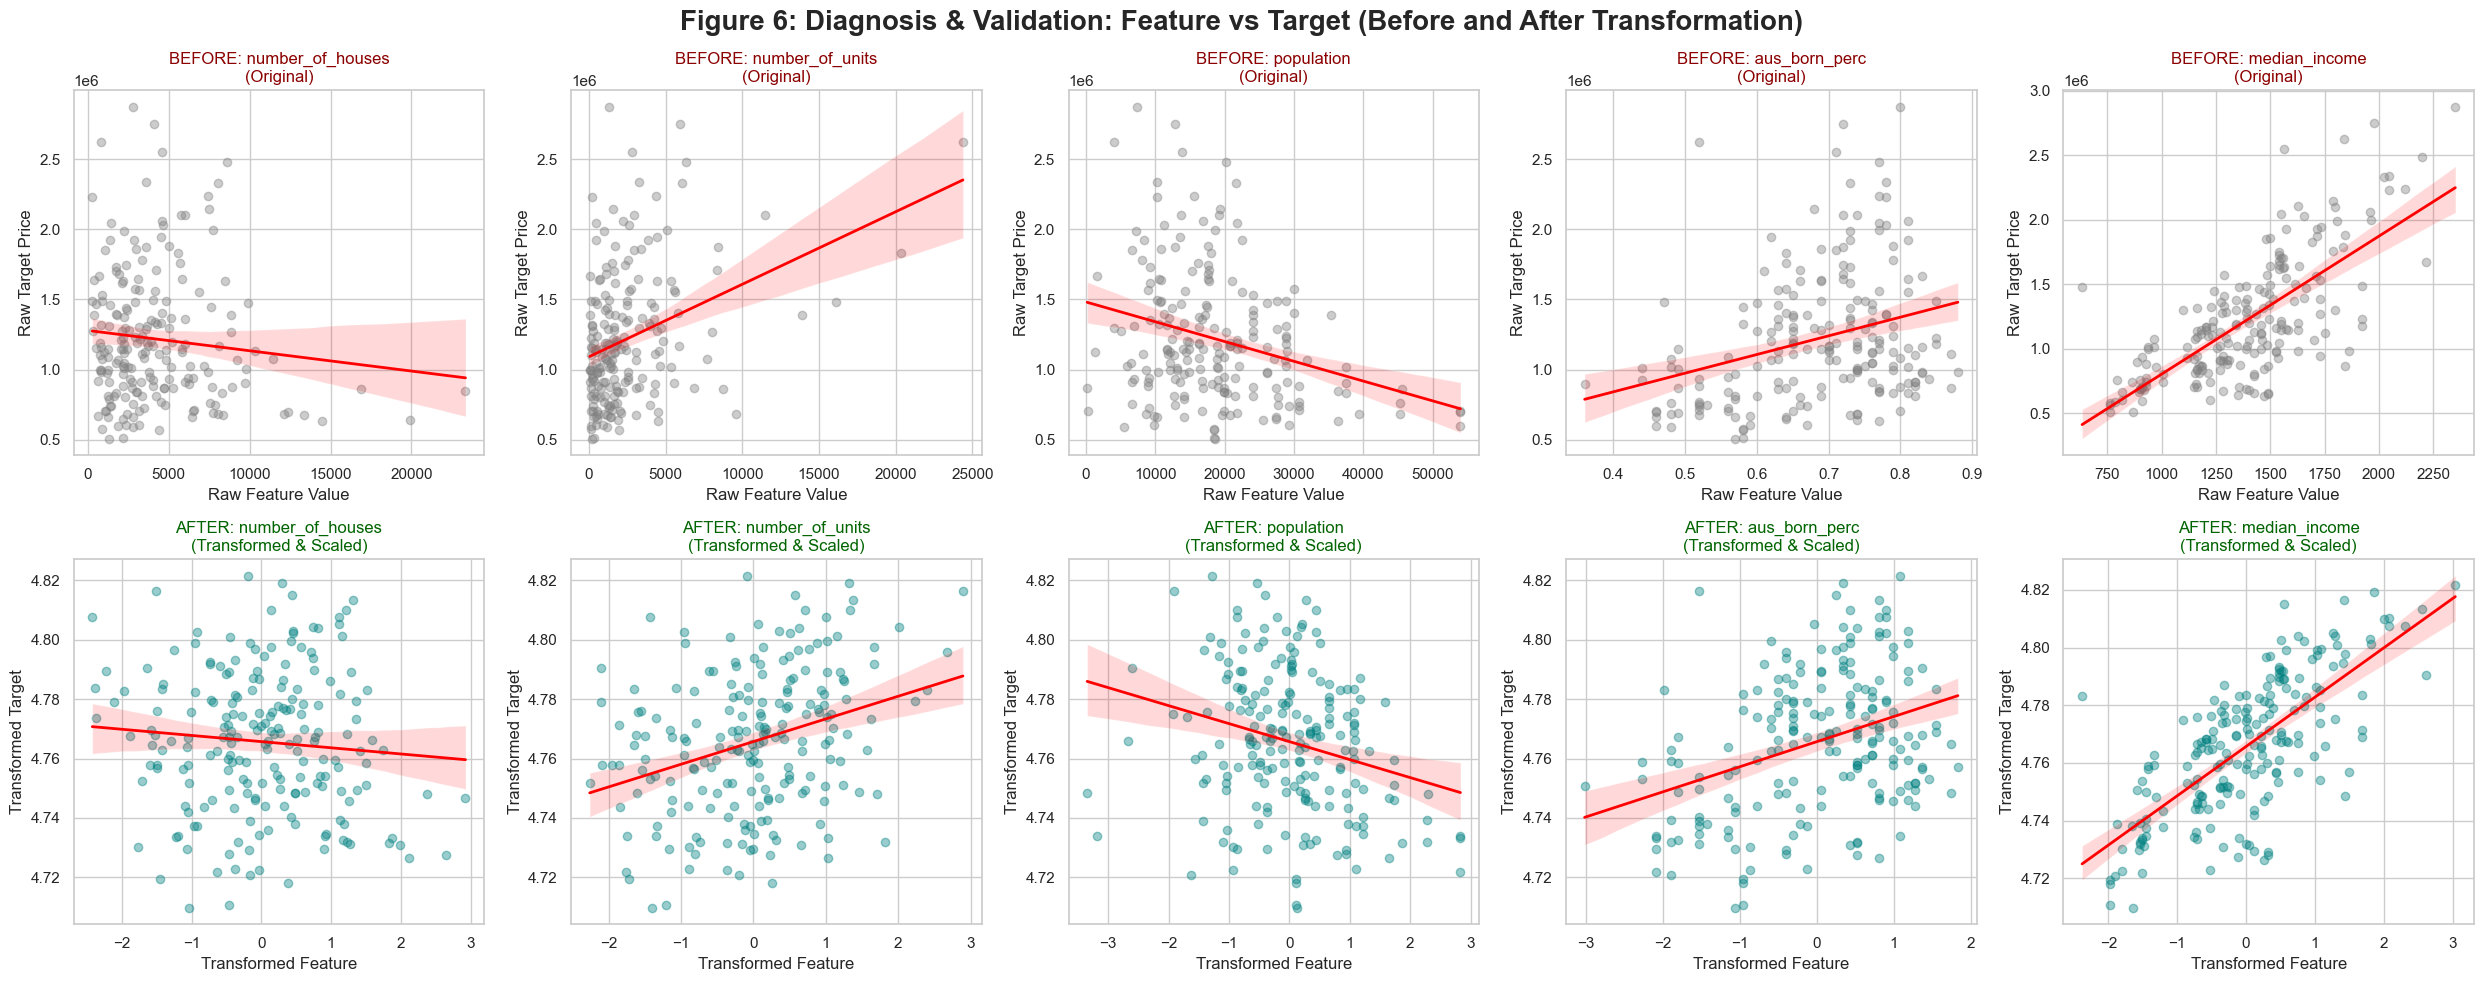

In [22]:
# ==========================================
# Figure 6: Each feature vs house price, before and after transformation & scaling
# ==========================================
fig, axes = plt.subplots(2, len(features), figsize=(25, 10))
fig.suptitle('Figure 6: Diagnosis & Validation: Feature vs Target (Before and After Transformation)',
             fontsize=20, fontweight='bold')

for i, col in enumerate(features):

    # Top row: raw data (no processing applied)
    sns.regplot(x=df[col], y=df[target], ax=axes[0, i],
                scatter_kws={'alpha': 0.4, 'color': 'gray'},
                line_kws={'color': 'red', 'linewidth': 2})
    axes[0, i].set_title(f'BEFORE: {col}\n(Original)', fontsize=12, color='darkred')
    axes[0, i].set_xlabel('Raw Feature Value')
    axes[0, i].set_ylabel('Raw Target Price')

    # Bottom row: final data after skewness correction + feature scaling
    sns.regplot(x=final_scaled_data[col], y=final_scaled_data[target], ax=axes[1, i],
                scatter_kws={'alpha': 0.4, 'color': 'teal'},
                line_kws={'color': 'red', 'linewidth': 2})
    axes[1, i].set_title(f'AFTER: {col}\n(Transformed & Scaled)', fontsize=12, color='darkgreen')
    axes[1, i].set_xlabel('Transformed Feature')
    axes[1, i].set_ylabel('Transformed Target')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()